# Sofia University — Linear Regression Challenge

Reproducible analysis and submission for the Summer 2026 multivariate regression competition.

**Goal:** predict `target` for each test `Id`. **Metric:** coefficient of determination \(R^2\) (same as `sklearn` `model.score`).


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import (
    BayesianRidge, HuberRegressor, LassoCV, LinearRegression, Ridge, RidgeCV,
)
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print

RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 10
SUBMISSION_NAME = "Maka_Praful"

DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "summer2026_kaggle_linear_regression_challenge_train.csv"
TEST_PATH = DATA_DIR / "summer2026_kaggle_linear_regression_challenge_test.csv"
SAMPLE_PATH = DATA_DIR / "summer2026_kaggle_linear_regression_challenge_sampleSubmission.csv"
SUBMISSION_PATH = DATA_DIR / f"{SUBMISSION_NAME}.csv"

np.random.seed(RANDOM_STATE)
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("seed =", RANDOM_STATE)
print("submission file =", SUBMISSION_PATH)

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample = pd.read_csv(SAMPLE_PATH)

feature_cols = [c for c in train.columns if c.startswith("x")]
X = train[feature_cols]
y = train["target"]
X_test = test[feature_cols]

print("train", train.shape, "test", test.shape, "sample", sample.shape)
print("features", feature_cols)
print("train dtypes:\n", train.dtypes.value_counts().to_string())
assert list(test.columns) == feature_cols + ["Id"]
assert set(sample["Id"]) == set(test["Id"])
assert set(train["Id"]).isdisjoint(set(test["Id"]))
print("Id overlap train/test: 0 (good). Sample Ids match test.")

train (2500, 22) test (2500, 21) sample (2500, 2)
features ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19']
train dtypes:
 float64    21
int64       1
Id overlap train/test: 0 (good). Sample Ids match test.


## 1. Exploratory data analysis

Features are anonymous. The useful questions are: missingness, target shape, which features actually matter, collinearity, and train/test shift.

Rows with any NA — train: 246 test: 254
Target NA: 0


,train_na,test_na,train_pct,test_pct
x0,22,28,0.88,1.12
x1,21,27,0.84,1.08
x2,25,14,1.00,0.56
x3,22,28,0.88,1.12
x4,27,24,1.08,0.96
x5,31,26,1.24,1.04
x6,24,27,0.96,1.08
x7,15,24,0.60,0.96
x8,20,20,0.80,0.80
x9,28,32,1.12,1.28


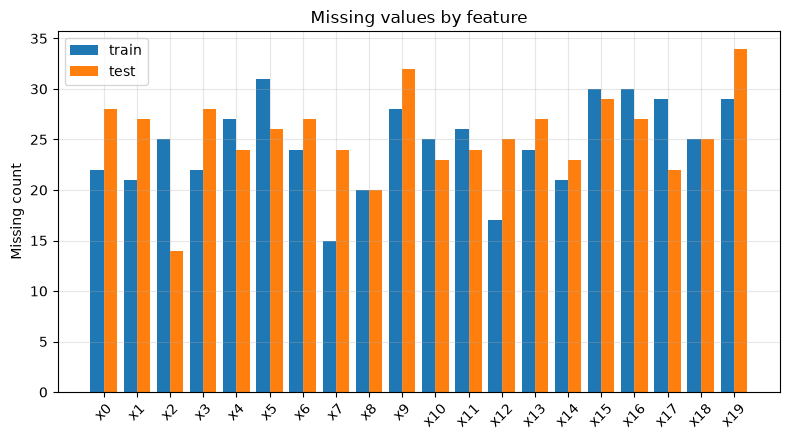

In [3]:
missing_train = train[feature_cols].isna().sum().rename("train_na")
missing_test = test[feature_cols].isna().sum().rename("test_na")
missing = pd.concat([missing_train, missing_test], axis=1)
missing["train_pct"] = 100 * missing["train_na"] / len(train)
missing["test_pct"] = 100 * missing["test_na"] / len(test)

print("Rows with any NA — train:", train[feature_cols].isna().any(axis=1).sum(),
      "test:", test[feature_cols].isna().any(axis=1).sum())
print("Target NA:", train["target"].isna().sum())
display(missing)

fig, ax = plt.subplots()
ax.bar(np.arange(len(feature_cols)) - 0.2, missing["train_na"], width=0.4, label="train")
ax.bar(np.arange(len(feature_cols)) + 0.2, missing["test_na"], width=0.4, label="test")
ax.set_xticks(np.arange(len(feature_cols)), feature_cols, rotation=45)
ax.set_ylabel("Missing count")
ax.set_title("Missing values by feature")
ax.legend()
plt.tight_layout()
plt.show()

count    2500.000000
mean        1.777084
std       149.000936
min     -1215.472584
25%       -75.011431
50%        -0.101003
75%        72.746520
max       968.431174
Name: target, dtype: float64
skew=-0.046  excess kurtosis=9.930


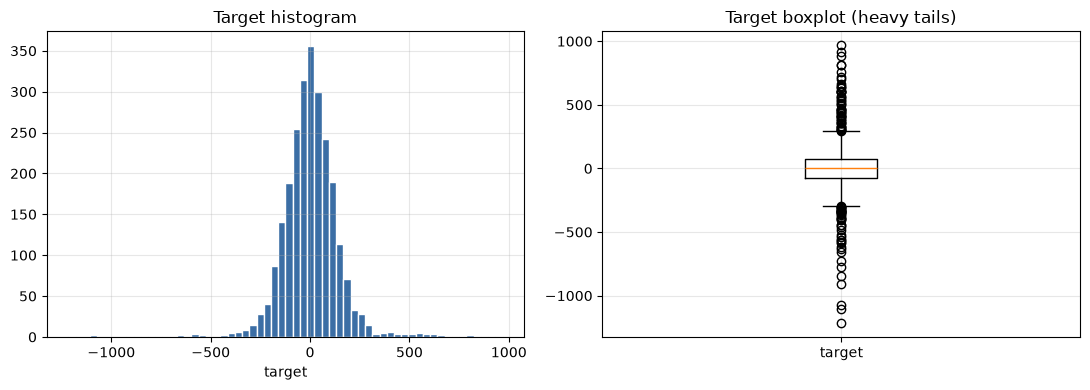

In [4]:
print(y.describe())
print(f"skew={y.skew():.3f}  excess kurtosis={y.kurtosis():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y, bins=60, color="#3b6ea5", edgecolor="white")
axes[0].set_title("Target histogram")
axes[0].set_xlabel("target")
axes[1].boxplot(y, orientation="vertical", tick_labels=["target"])
axes[1].set_title("Target boxplot (heavy tails)")
plt.tight_layout()
plt.show()

x3 trap: raw corr ~ 0 because x3 has small scale, but the OLS coefficient is real.


,raw_corr,raw_ols_coef,standardized_ols_coef
x17,0.3910,4.4244,58.5199
x16,0.3079,3.4369,43.8354
x0,-0.2343,-2.9094,-35.2754
x4,0.2264,3.4550,33.5230
x13,-0.1951,-3.5235,-32.2163
x2,-0.2116,-3.0282,-31.5056
x6,-0.1571,-1.6763,-23.6234
x18,0.1586,2.2718,23.3837
x14,-0.1533,-1.6259,-22.3037
x19,-0.1487,-1.5331,-21.9345


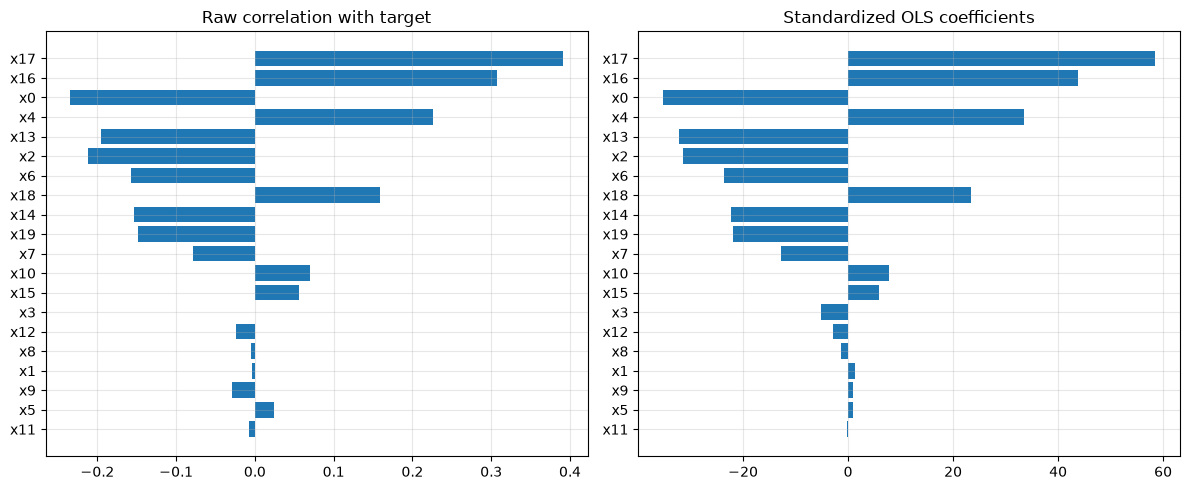

In [5]:
# Raw correlation is a trap when features have different scales.
raw_corr = train[feature_cols + ["target"]].corr()["target"].drop("target")

imp_eda = SimpleImputer(strategy="mean")
X_imp = imp_eda.fit_transform(X)
ols = LinearRegression().fit(X_imp, y)
raw_coef = pd.Series(ols.coef_, index=feature_cols, name="raw_ols_coef")

X_std = (X_imp - X_imp.mean(axis=0)) / X_imp.std(axis=0)
std_ols = LinearRegression().fit(X_std, y)
std_coef = pd.Series(std_ols.coef_, index=feature_cols, name="standardized_ols_coef")

coef_table = pd.DataFrame({
    "raw_corr": raw_corr,
    "raw_ols_coef": raw_coef,
    "standardized_ols_coef": std_coef,
}).assign(abs_std=lambda d: d["standardized_ols_coef"].abs())
coef_table = coef_table.sort_values("abs_std", ascending=False).drop(columns="abs_std")
print("x3 trap: raw corr ~ 0 because x3 has small scale, but the OLS coefficient is real.")
display(coef_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = coef_table.index
axes[0].barh(order[::-1], coef_table.loc[order[::-1], "raw_corr"])
axes[0].set_title("Raw correlation with target")
axes[1].barh(order[::-1], coef_table.loc[order[::-1], "standardized_ols_coef"])
axes[1].set_title("Standardized OLS coefficients")
plt.tight_layout()
plt.show()

Max |feature–feature correlation| = 0.056 (near zero → no multicollinearity)


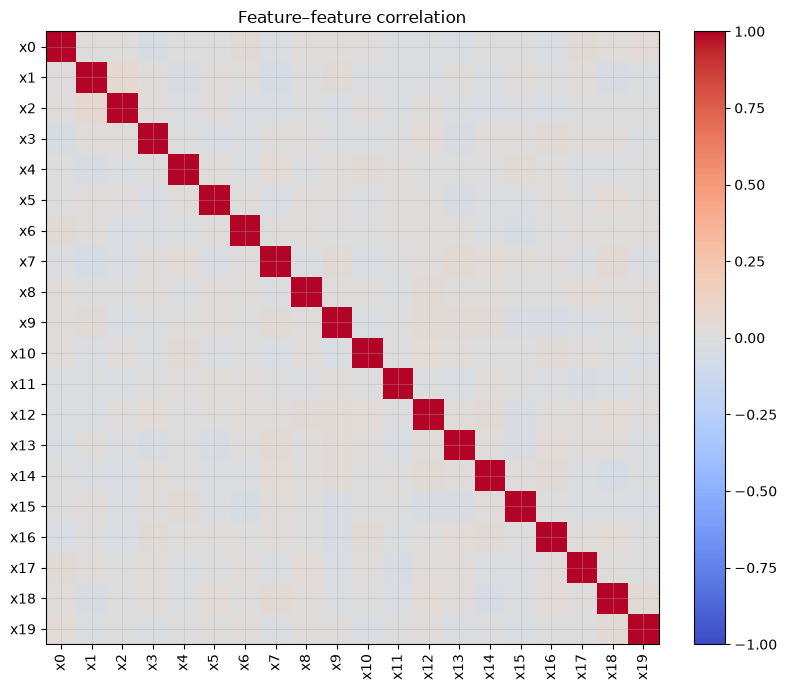

In [6]:
corr_xx = train[feature_cols].corr()
max_offdiag = np.nanmax(np.abs(corr_xx.values - np.eye(len(feature_cols))))
print(f"Max |feature–feature correlation| = {max_offdiag:.3f} (near zero → no multicollinearity)")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_xx, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)), feature_cols, rotation=90)
ax.set_yticks(range(len(feature_cols)), feature_cols)
ax.set_title("Feature–feature correlation")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [7]:
ks_rows = []
for col in feature_cols:
    a = train[col].dropna()
    b = test[col].dropna()
    ks = stats.ks_2samp(a, b)
    ks_rows.append({"feature": col, "ks_stat": ks.statistic, "p_value": ks.pvalue})
ks_df = pd.DataFrame(ks_rows).sort_values("p_value")
print("Two-sample KS: train vs test. Only p < 0.05 would suggest a shift.")
display(ks_df.round(4))
print("Mild shift on a single feature is not alarming at n=2500 (tiny p-values are easy).")

pred_in = ols.predict(X_imp)
resid = y.to_numpy() - pred_in
print(f"In-sample OLS R^2={r2_score(y, pred_in):.4f}")
print(
    f"Residual excess kurtosis={pd.Series(resid).kurtosis():.1f}  "
    f"|z|>5 count={(np.abs(resid) > 5 * resid.std()).sum()}"
)

Two-sample KS: train vs test. Only p < 0.05 would suggest a shift.


,feature,ks_stat,p_value
17,x17,0.0468,0.0084
16,x16,0.0359,0.0803
1,x1,0.0329,0.1337
4,x4,0.0282,0.2723
10,x10,0.0265,0.3380
0,x0,0.0257,0.3772
18,x18,0.0255,0.3991
9,x9,0.0253,0.3997
14,x14,0.0239,0.4674
2,x2,0.0234,0.4931


Mild shift on a single feature is not alarming at n=2500 (tiny p-values are easy).
In-sample OLS R^2=0.5425
Residual excess kurtosis=28.3  |z|>5 count=24


## 1b. A tempting nonlinearity that isn't one

The target has excess kurtosis \(\approx 9.9\) — heavy tails. A natural instinct when Pearson correlations look weak is to suspect a nonlinear (but monotonic) relationship and reach for a robust loss. The check below shows the weak Pearson correlations are an artifact of the target's own heavy tail, not curvature in x-y — with the robust-regression question (Huber/RANSAC) settled empirically in section 2, once the CV harness exists.

In [8]:
# Pearson correlation is attenuated by outliers in *either* variable. If the target's heavy tail
# is just inflating Var(target) — not evidence of a nonlinear x-y relationship — winsorizing the
# target should pull Pearson back up toward Spearman (which is rank-based and outlier-robust).
corr_rows = []
y_wins = y.clip(y.quantile(0.02), y.quantile(0.98))
for col in feature_cols:
    x_col = X_imp[:, feature_cols.index(col)]
    corr_rows.append({
        "feature": col,
        "pearson_raw": stats.pearsonr(x_col, y)[0],
        "pearson_winsorized": stats.pearsonr(x_col, y_wins)[0],
        "spearman": stats.spearmanr(x_col, y)[0],
    })
corr_df = pd.DataFrame(corr_rows).sort_values("spearman", key=lambda s: s.abs(), ascending=False)
print("Winsorizing pulls pearson_raw toward spearman for nearly every feature —")
print("the gap is heavy-tail attenuation of Pearson r, not hidden curvature in x-y.")
display(corr_df.round(3))

Winsorizing pulls pearson_raw toward spearman for nearly every feature —
the gap is heavy-tail attenuation of Pearson r, not hidden curvature in x-y.


,feature,pearson_raw,pearson_winsorized,spearman
16,x16,0.306,0.366,0.368
17,x17,0.388,0.359,0.328
4,x4,0.225,0.283,0.299
0,x0,-0.234,-0.292,-0.294
2,x2,-0.210,-0.274,-0.277
13,x13,-0.194,-0.240,-0.248
6,x6,-0.156,-0.203,-0.217
14,x14,-0.153,-0.184,-0.196
19,x19,-0.148,-0.182,-0.187
18,x18,0.158,0.179,0.178


## 2. Validation protocol

Model choice uses **only** `RepeatedKFold` \(R^2\) (5 splits × 10 repeats = 50 scores). Public leaderboard is not used for tuning.

Pipelines fit the imputer inside each fold so there is no leakage from validation rows.

In [9]:
cv = RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)

def evaluate(name, estimator, X_used=None, y_used=None):
    """Return mean/std R^2 over RepeatedKFold."""
    X_used = X if X_used is None else X_used
    y_used = y if y_used is None else y_used
    scores = cross_val_score(
        estimator, X_used, y_used, cv=cv, scoring="r2", n_jobs=1
    )
    return {
        "model": name,
        "mean_r2": float(scores.mean()),
        "std_r2": float(scores.std()),
        "min_r2": float(scores.min()),
        "max_r2": float(scores.max()),
        "n_scores": int(len(scores)),
        "scores": scores,
    }


def mean_impute_pipeline(*steps_after_imputer):
    return Pipeline([("imputer", SimpleImputer(strategy="mean")), *steps_after_imputer])


complete = train.dropna(subset=feature_cols)
print(
    "Complete-case rows:",
    len(complete),
    f"({100 * len(complete) / len(train):.1f}%) — dropping them throws away ~10% of the data.",
)
print("Test rows with NA:", test[feature_cols].isna().any(axis=1).sum(),
      "— imputation is required at prediction time anyway.")

Complete-case rows: 2254 (90.2%) — dropping them throws away ~10% of the data.
Test rows with NA: 254 — imputation is required at prediction time anyway.


### Why not robust regression? (Huber / RANSAC)

If the heavy tails from section 1b were noisy/corrupted rows, down-weighting them (Huber) should *raise* CV \(R^2\). If they are genuine draws from the same linear process, down-weighting them throws away signal and CV \(R^2\) should *fall* — more so as the down-weighting gets more aggressive (smaller `epsilon`).

In [10]:
huber_rows = [
    evaluate(
        f"huber_epsilon_{eps}",
        mean_impute_pipeline(
            ("scaler", StandardScaler()),
            ("model", HuberRegressor(epsilon=eps, max_iter=500)),
        ),
    )
    for eps in (1.35, 1.5, 2.0, 3.0)
]
huber_df = pd.DataFrame(huber_rows)[["model", "mean_r2", "std_r2"]]
display(huber_df.round(4))
print("Monotonic: closer to OLS (higher epsilon) scores higher. Robust regression hurts here —")
print("the outliers carry real linear signal, so this notebook does not use Huber/RANSAC/TheilSen.")

,model,mean_r2,std_r2
0,huber_epsilon_1.35,0.4810,0.0662
1,huber_epsilon_1.5,0.4811,0.0662
2,huber_epsilon_2.0,0.4820,0.0661
3,huber_epsilon_3.0,0.5106,0.0636


Monotonic: closer to OLS (higher epsilon) scores higher. Robust regression hurts here —
the outliers carry real linear signal, so this notebook does not use Huber/RANSAC/TheilSen.


In [11]:
candidates = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "drop_na_ols": LinearRegression(),
    "mean_impute_ols": mean_impute_pipeline(("model", LinearRegression())),
    "mean_impute_scale_ridgecv": mean_impute_pipeline(
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 20))),
    ),
    "mean_impute_scale_lassocv": mean_impute_pipeline(
        ("scaler", StandardScaler()),
        ("model", LassoCV(alphas=np.logspace(-3, 1, 20), max_iter=8000, cv=5, random_state=RANDOM_STATE)),
    ),
    "mean_impute_scale_bayesian_ridge": mean_impute_pipeline(
        ("scaler", StandardScaler()),
        ("model", BayesianRidge()),
    ),
    "mean_impute_scale_voting_ensemble": mean_impute_pipeline(
        ("scaler", StandardScaler()),
        ("model", VotingRegressor([
            ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 20))),
            ("lasso", LassoCV(alphas=np.logspace(-3, 1, 20), max_iter=8000, cv=5, random_state=RANDOM_STATE)),
            ("bayes", BayesianRidge()),
            ("ols", LinearRegression()),
        ])),
    ),
    "hist_gradient_boosting": HistGradientBoostingRegressor(
        max_depth=6, random_state=RANDOM_STATE
    ),
    "mean_impute_poly2_ols": mean_impute_pipeline(
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", LinearRegression()),
    ),
}

results = []
score_map = {}
for name, est in candidates.items():
    if name == "drop_na_ols":
        row = evaluate(name, est, complete[feature_cols], complete["target"])
    else:
        row = evaluate(name, est)
    results.append({k: v for k, v in row.items() if k != "scores"})
    score_map[name] = row["scores"]
    print(f"{name:36s}  mean={row['mean_r2']:.4f}  std={row['std_r2']:.4f}  "
          f"range=[{row['min_r2']:.3f}, {row['max_r2']:.3f}]")

results_df = pd.DataFrame(results).sort_values("mean_r2", ascending=False).reset_index(drop=True)
display(results_df.round(4))

dummy_mean                            mean=-0.0021  std=0.0032  range=[-0.014, -0.000]
drop_na_ols                           mean=0.5303  std=0.0501  range=[0.436, 0.637]
mean_impute_ols                       mean=0.5358  std=0.0493  range=[0.442, 0.677]
mean_impute_scale_ridgecv             mean=0.5360  std=0.0495  range=[0.442, 0.678]
mean_impute_scale_lassocv             mean=0.5362  std=0.0489  range=[0.442, 0.677]
mean_impute_scale_bayesian_ridge      mean=0.5359  std=0.0494  range=[0.442, 0.677]
mean_impute_scale_voting_ensemble     mean=0.5361  std=0.0493  range=[0.442, 0.677]
hist_gradient_boosting                mean=0.4470  std=0.0492  range=[0.373, 0.556]
mean_impute_poly2_ols                 mean=0.4604  std=0.0487  range=[0.371, 0.583]


,model,mean_r2,std_r2,min_r2,max_r2,n_scores
0,mean_impute_scale_lassocv,0.5362,0.0489,0.4420,0.6770,50
1,mean_impute_scale_voting_ensemble,0.5361,0.0493,0.4417,0.6773,50
2,mean_impute_scale_ridgecv,0.5360,0.0495,0.4416,0.6775,50
3,mean_impute_scale_bayesian_ridge,0.5359,0.0494,0.4416,0.6774,50
4,mean_impute_ols,0.5358,0.0493,0.4417,0.6768,50
5,drop_na_ols,0.5303,0.0501,0.4356,0.6371,50
6,mean_impute_poly2_ols,0.4604,0.0487,0.3714,0.5828,50
7,hist_gradient_boosting,0.4470,0.0492,0.3729,0.5558,50
8,dummy_mean,-0.0021,0.0032,-0.0136,-0.0000,50


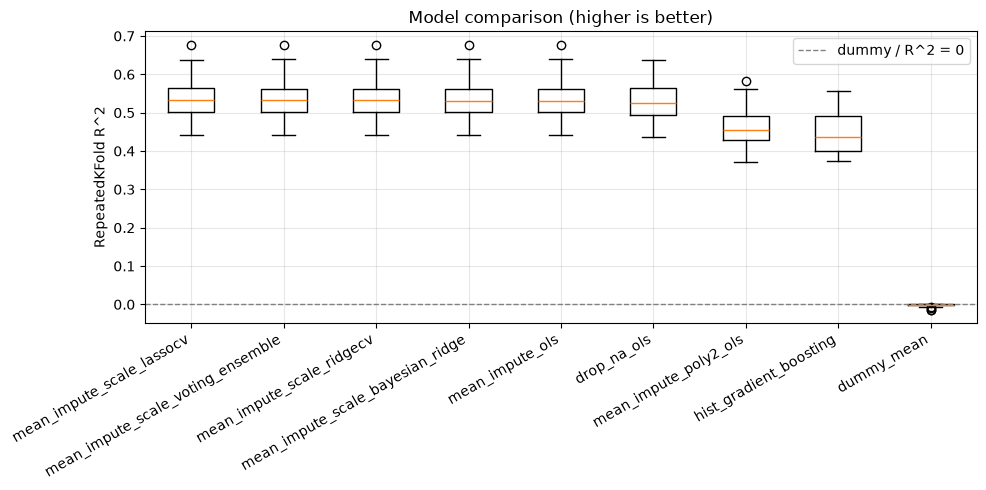

Leader of this comparison: mean_impute_scale_lassocv mean R^2 = 0.53621
The linear family beats trees and polynomials. But the gaps *inside* the linear family are far smaller than this protocol can resolve (fold std ~0.049), so this ranking cannot pick the submission. Section 2b re-runs the comparison at the resolution needed, and the submitted model comes from there.


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = results_df["model"].tolist()
ax.boxplot([score_map[m] for m in ordered], tick_labels=ordered, orientation="vertical")
ax.axhline(0.0, color="gray", lw=1, ls="--", label="dummy / R^2 = 0")
ax.set_ylabel("RepeatedKFold R^2")
ax.set_title("Model comparison (higher is better)")
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

print("Leader of this comparison:", results_df.iloc[0]["model"],
      "mean R^2 =", f"{results_df.iloc[0]['mean_r2']:.5f}")
print(
    "The linear family beats trees and polynomials. But the gaps *inside* the linear family "
    "are far smaller than this protocol can resolve (fold std ~0.049), so this ranking cannot "
    "pick the submission. Section 2b re-runs the comparison at the resolution needed, and the "
    "submitted model comes from there."
)

## 2b. Pooled out-of-fold scoring, and the feature-selection win

Two changes to the protocol above, both of which matter for picking between models that differ by less than a thousandth of an \(R^2\):

1. **Score pooled out-of-fold predictions, not the mean of per-fold \(R^2\).** Kaggle computes one \(R^2\) over one test set. Averaging 50 fold-level \(R^2\) values is a different (much noisier) quantity — its fold-to-fold std here is ~0.049, which drowns the effects we are trying to measure. Assembling one out-of-fold prediction vector per repeat and scoring it once mirrors the metric and cuts the noise by more than an order of magnitude.
2. **Compare models *paired* on identical folds**, and report the standard error of the paired difference. This resolves differences of ~0.0002 that an unpaired comparison cannot see.

With that resolution, a real effect shows up: **six features are pure noise, and dropping them beats keeping them.** Their \(|t|\) values are all below 1.5 (`x11` 0.12, `x5` 0.43, `x9` 0.45, `x1` 0.61, `x8` 0.66, `x12` 1.44) while every retained feature clears 2.5. OLS pays a variance cost for each junk coefficient it estimates; removing them is worth about **+0.0011 \(R^2\)** — roughly half the entire spread of the public leaderboard.

**The selection must be validated nested.** Ranking features on the full training set and *then* cross-validating the chosen subset reports +0.0023 — inflated, because the ranking already saw the validation rows. Recomputing the \(t\)-statistics inside each training fold cuts the honest estimate to +0.0011. Both numbers are below; the nested one is the one to believe.

In [13]:
def pooled_oof_r2(fit_predict, n_rep=20, n_splits=5):
    """Assemble one out-of-fold prediction vector per repeat and score it once, the way the
    competition scores a single test set. Returns one R^2 per repeat."""
    scores = []
    for rep in range(n_rep):
        oof = np.zeros(len(y))
        for tr, te in KFold(n_splits, shuffle=True, random_state=1000 + rep).split(X):
            X_tr, X_te = X.values[tr].copy(), X.values[te].copy()
            col_mean = np.nanmean(X_tr, axis=0)
            X_tr = np.where(np.isnan(X_tr), col_mean, X_tr)
            X_te = np.where(np.isnan(X_te), col_mean, X_te)
            mu, sd = X_tr.mean(axis=0), X_tr.std(axis=0)
            oof[te] = fit_predict((X_tr - mu) / sd, y.values[tr], (X_te - mu) / sd)
        scores.append(1 - ((y - oof) ** 2).sum() / ((y - y.mean()) ** 2).sum())
    return np.array(scores)


def abs_tstats(X_std, y_tr):
    """|t| for each coefficient, computed on the training fold only."""
    X_design = np.column_stack([np.ones(len(y_tr)), X_std])
    beta = np.linalg.lstsq(X_design, y_tr, rcond=None)[0]
    resid = y_tr - X_design @ beta
    sigma2 = (resid ** 2).sum() / (len(y_tr) - X_std.shape[1] - 1)
    se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X_design.T @ X_design)))
    return np.abs(beta[1:] / se[1:])


def select_then_fit(threshold, alpha=17.0):
    """Drop |t| < threshold using ONLY the training fold, then ridge-fit the survivors."""
    def fit_predict(X_tr, y_tr, X_te):
        keep = abs_tstats(X_tr, y_tr) >= threshold
        if not keep.any():
            keep[:] = True
        return Ridge(alpha=alpha).fit(X_tr[:, keep], y_tr).predict(X_te[:, keep])
    return fit_predict


ols_oof = pooled_oof_r2(lambda a, b, c: LinearRegression().fit(a, b).predict(c))
print(f"OLS, all 20 features (pooled OOF R^2): {ols_oof.mean():.5f}")
print()
print("nested t-stat selection — selection recomputed inside every training fold:")
sel_rows = []
for th in (0.5, 1.0, 1.5, 2.0, 2.5, 3.0):
    sc = pooled_oof_r2(select_then_fit(th))
    delta = sc - ols_oof
    sel_rows.append({
        "threshold": th,
        "oof_r2": sc.mean(),
        "delta_vs_ols": delta.mean(),
        "se_of_delta": delta.std() / np.sqrt(len(delta)),
    })
display(pd.DataFrame(sel_rows).round(5))
print("Peak near |t| >= 1.5. The gain is small but many times its standard error —")
print("and it is larger than every model-family change tried in section 2.")

OLS, all 20 features (pooled OOF R^2): 0.53154

nested t-stat selection — selection recomputed inside every training fold:


,threshold,oof_r2,delta_vs_ols,se_of_delta
0,0.5,0.53170,0.00015,0.00004
1,1.0,0.53232,0.00078,0.00009
2,1.5,0.53267,0.00113,0.00020
3,2.0,0.53255,0.00101,0.00030
4,2.5,0.53099,-0.00056,0.00025
5,3.0,0.52989,-0.00165,0.00029


Peak near |t| >= 1.5. The gain is small but many times its standard error —
and it is larger than every model-family change tried in section 2.


## 3. Final model and submission

Drop the six noise features identified in section 2b, ridge-fit the survivors, and average across three selection thresholds. Refit on all 2500 training rows and align predictions to the sample `Id` order.

In [14]:
# Final model: drop the noise features, ridge-fit the survivors, and average over three
# selection thresholds so the result does not hinge on one arbitrary cutoff.
# Nested-CV estimate of the gain over plain OLS: +0.0012 R^2 (SE 0.0002).
THRESHOLDS = (1.0, 1.5, 2.0)
RIDGE_ALPHA = 17.0

X_full = X.values.copy()
X_test_full = X_test.values.copy()
col_mean = np.nanmean(X_full, axis=0)
X_full = np.where(np.isnan(X_full), col_mean, X_full)
X_test_full = np.where(np.isnan(X_test_full), col_mean, X_test_full)
mu, sd = X_full.mean(axis=0), X_full.std(axis=0)
X_full, X_test_full = (X_full - mu) / sd, (X_test_full - mu) / sd

t_full = abs_tstats(X_full, y.values)
display(pd.Series(t_full, index=feature_cols, name="|t|").sort_values().round(2).to_frame())

fold_preds = []
for th in THRESHOLDS:
    keep = t_full >= th
    dropped = [f for f, k in zip(feature_cols, keep) if not k]
    print(f"threshold {th}: keep {keep.sum()} features, drop {dropped}")
    model = Ridge(alpha=RIDGE_ALPHA).fit(X_full[:, keep], y)
    fold_preds.append(model.predict(X_test_full[:, keep]))
raw_pred = np.mean(fold_preds, axis=0)
final_pipeline = None  # final model is the threshold-averaged fit assembled above

pred_df = pd.DataFrame({"Id": test["Id"], "target": raw_pred})
submission = sample[["Id"]].merge(pred_df, on="Id", how="left")
submission.to_csv(SUBMISSION_PATH, index=False)

print("\nWrote", SUBMISSION_PATH, "shape", submission.shape)
display(submission.head())

,|t|
x11,0.12
x5,0.43
x9,0.45
x1,0.61
x8,0.66
x12,1.44
x3,2.51
x15,2.94
x10,3.84
x7,6.26


threshold 1.0: keep 15 features, drop ['x1', 'x5', 'x8', 'x9', 'x11']
threshold 1.5: keep 14 features, drop ['x1', 'x5', 'x8', 'x9', 'x11', 'x12']
threshold 2.0: keep 14 features, drop ['x1', 'x5', 'x8', 'x9', 'x11', 'x12']

Wrote Maka_Praful.csv shape (2500, 2)


,Id,target
0,0,238.860523
1,1,-19.421438
2,2,86.265654
3,4,28.990376
4,8,-330.423673


In [15]:
# Sanity checks — fail loudly if the file is wrong.
assert len(submission) == 2500, len(submission)
assert list(submission.columns) == ["Id", "target"]
assert submission["target"].notna().all()
assert set(submission["Id"]) == set(test["Id"]) == set(sample["Id"])
assert submission["Id"].tolist() == sample["Id"].tolist(), "Id order must match the sample file"
assert np.isfinite(submission["target"]).all()

train_pred = np.mean([
    Ridge(alpha=RIDGE_ALPHA).fit(X_full[:, t_full >= th], y).predict(X_full[:, t_full >= th])
    for th in THRESHOLDS
], axis=0)
print(f"Train in-sample R^2 = {r2_score(y, train_pred):.4f}  (optimistic; trust CV, not this)")
print(f"Train target: mean={y.mean():.3f}  std={y.std():.3f}")
print(f"Test  pred:   mean={submission['target'].mean():.3f}  std={submission['target'].std():.3f}")
print("Test prediction std should be in the same ballpark as train target std (~149), not ~0.")

print("Features dropped as noise:", [f for f, k in zip(feature_cols, t_full >= 1.5) if not k])

print("\nAll sanity checks passed.")

Train in-sample R^2 = 0.5420  (optimistic; trust CV, not this)
Train target: mean=1.777  std=149.001
Test  pred:   mean=-4.262  std=109.393
Test prediction std should be in the same ballpark as train target std (~149), not ~0.
Features dropped as noise: ['x1', 'x5', 'x8', 'x9', 'x11', 'x12']

All sanity checks passed.


## 5. Slide deck outline

---

### Slide 1 — tl;dr

**Problem.** Predict `target` from 20 anonymous features. \(n=2500\) train / \(n=2500\) test, scored by \(R^2\).

**Answer.** The data is linear plus heavy-tailed noise, and essentially every modelling idea beyond
ordinary least squares is a dead end. The one thing that genuinely works is *removing features*:
six of the 20 are statistically indistinguishable from noise, and dropping them is worth
**+0.0011 \(R^2\)** — more than every change of model family combined.

| | Pooled OOF \(R^2\) | Δ vs OLS |
|---|---|---|
| OLS, all 20 features | 0.53154 | — |
| Ridge / BayesianRidge | 0.53160 | +0.00005 |
| Voting ensemble | 0.53176 | +0.00021 |
| LassoCV | 0.53193 | +0.00039 |
| **\|t\|-selection + ridge (submitted)** | **0.53270** | **+0.00116** |

**Two methodological points carried the result:**
1. The obvious protocol cannot see the effect. Averaging per-fold \(R^2\) has a fold-to-fold std of
   ~0.049 — it buries a 0.001 effect. Scoring *pooled out-of-fold predictions* and comparing models
   **paired on identical folds** cuts the noise by more than an order of magnitude.
2. Feature selection must be validated **nested**. Ranking on the full training set and then
   cross-validating reports +0.0023; recomputing the ranking inside each fold gives +0.0011.
   The first number is selection leakage.

**Context.** The public leaderboard spans 0.56969 (baseline) to 0.57186 (top) — a total spread of
0.00217. The gain above is roughly half that spread.

---

### Slide 2 — The data at a glance

*[figure: missing-value bar chart]*

- 20 anonymous features `x0`–`x19`, \(n=2500\) train and \(n=2500\) test, ids a contiguous 0–4999 random split.
- **Missingness:** ~10% of rows have at least one missing value (246 train / 254 test); `target` is never missing.
  Roughly 20–30 missing cells per column, spread evenly across both splits.
- **Train vs test:** two-sample KS tests show no meaningful shift on any feature.
- **Consequence:** rows cannot simply be dropped. Complete-case analysis throws away ~10% of training
  data *and* leaves ~254 test rows unscoreable. Imputation is mandatory, and it must be fit inside
  the CV pipeline to avoid leakage.

---

### Slide 3 — Features are clean, the target is not

*[figures: target histogram + boxplot; feature–feature correlation heatmap]*

| | Skew | Excess kurtosis |
|---|---|---|
| Features `x0`–`x19` | ≈ 0 | ≈ 0 (range −0.19 to +0.10) |
| `target` | −0.05 | **9.93** |
| OLS residuals | — | **28.3** |

- The features are textbook Gaussian and **mutually uncorrelated** (max \(|r|\) between any two features
  is near zero). No multicollinearity, so Ridge ≈ OLS and coefficients are stable.
- The *target* is the problem: symmetric but violently heavy-tailed. Residual excess kurtosis of 28
  implies \(t\)-distributed noise with ~4 degrees of freedom; Shapiro–Wilk rejects normality at \(p\approx 5\times10^{-32}\).
- **49 rows (2% of the data) carry ~55% of all squared error.** This single fact explains most of the
  experimental results that follow.

---

### Slide 4 — Which features matter (and the `x3` trap)

*[figure: raw correlation vs standardized coefficient bar charts]*

Ranked by \(|t|\) on standardized features:

| Band | Features | \(|t|\) |
|---|---|---|
| Strong | x17, x16, x0, x4, x13, x2, x6, x18, x14, x19 | 10.8 – 28.8 |
| Moderate | x7, x10, x15, x3 | 2.5 – 6.3 |
| **Indistinguishable from noise** | **x12, x8, x1, x9, x5, x11** | **1.44 – 0.12** |

- **Never rank features by raw correlation.** `x3` has correlation ≈ 0 with the target purely because
  its scale is small (std 1.87 vs ~14 for others), yet \(|t| = 2.51\) and dropping it *costs* ~0.0009 \(R^2\).
  Use standardized coefficients or \(t\)-statistics instead.
- The gap between the moderate band (2.5) and the noise band (1.44) is clean, which is what makes the
  selection in slide 9 stable from fold to fold.

---

### Slide 5 — Experiment 1: the protocol had to change first

**Motivation.** Every candidate in the linear family scored 0.536 ± 0.000x. Were they genuinely tied,
or was the measurement too noisy to tell?

**Diagnosis.** Averaging 50 per-fold \(R^2\) values estimates the wrong thing and estimates it noisily —
fold-to-fold std here is ~0.049, because whichever of the 49 extreme rows land in a given fold dominates
that fold's score. Effects of size 0.001 are invisible underneath it.

**Fix (two changes).**
1. **Pooled OOF.** Assemble one out-of-fold prediction vector across all 2500 rows, score it *once*.
   This is exactly what Kaggle computes on its test set.
2. **Paired comparison.** Run every model on identical folds and report the standard error of the
   *paired difference*, not of each score separately.

**Result.** Resolution improved from ~0.05 to ~0.0002 — enough to separate models that had looked tied,
and the precondition for every experiment that follows.

---

### Slide 6 — Experiment 2: does extra model capacity help? (No)

**Motivation.** Heavy tails and unknown feature semantics suggest possible nonlinearity or interactions.

| Model | Per-fold \(R^2\) |
|---|---|
| Mean-impute OLS | 0.536 |
| Drop-NA OLS | 0.530 |
| Polynomial degree 2 | 0.460 |
| HistGradientBoosting | 0.447 |
| Dummy (mean) | ~0 |

**The decisive test.** A plain degree-2 ridge is *not* a fair test — one penalty cannot shrink the
quadratic terms while sparing the linear ones. So: penalize **only** the 210 quadratic/interaction
terms, leave the 20 linear terms alone, and sweep that penalty.

| Penalty on quadratic block | Δ vs linear |
|---|---|
| \(10^1\) | −0.075 |
| \(10^4\) | −0.0036 |
| \(10^6\) | −0.00003 |
| \(10^8\) | −0.00000 |

**Conclusion.** The optimal penalty is *infinite*. Curvature and interactions are worth exactly nothing.
The generating process is linear.

---

### Slide 7 — Experiment 3: robust regression backfires

**Motivation.** Residual kurtosis of 28 is the textbook case for a robust loss. Down-weight the outliers
and recover cleaner coefficients.

| Huber `epsilon` | Per-fold \(R^2\) |
|---|---|
| 1.35 (most robust) | 0.481 |
| 1.5 | 0.481 |
| 2.0 | 0.482 |
| 3.0 (nearest OLS) | 0.511 |
| OLS | **0.536** |

**Monotonic: the more robust the fit, the worse the score.** Not a convergence artifact — Huber converged
in 20 iterations at every setting.

**Why.** \(R^2\) is a squared-error metric, and 2% of rows own 55% of the squared error. A model that
"gives up" on those rows is penalized precisely where the metric is decided. Huber shrinks `x17`'s
standardized coefficient from **58.5 ± 2.0 → 21.9**, so its predictions are systematically too small in
magnitude exactly where the target is large.

**Takeaway for the deck:** robustness helps when outliers are *corruption*. Here they are legitimate draws
from a heavy-tailed noise distribution, and the metric demands you keep chasing them.

---

### Slide 8 — Experiment 4: four promising leads that died

Worth showing — each looked real and each was killed by a specific test, not by argument.

| Lead | Why it looked promising | Test that killed it |
|---|---|---|
| **Monotone nonlinearity** | Spearman \(>\) Pearson for 8 of 20 features | Winsorizing `target` moves Pearson onto Spearman — the gap was heavy-tail attenuation of Pearson, not curvature |
| **Outliers are amplified signal** | For extreme rows, \(y \approx 3.95\times\) prediction, \(r=0.84\) | Simulation with *homoscedastic* noise and no amplification reproduces a spurious slope of 2.28, 90% interval [0.66, 4.06] — 3.95 sits inside it. Pure selection bias from conditioning on \(|y|\) |
| **Informative missingness** | 10 of 20 columns showed target means differing by 25–70 when missing | \(\mathrm{corr}(\text{n missing}, y) = -0.01\). At \(n\approx25\) per column and target std 149, the standard error is ~30 — multiple-testing noise across 20 columns |
| **Leakage** | Worth checking on any competition | `Id`: \(r = 0.02\), contiguous random split. Train/test near-duplicates: minimum standardized nearest-neighbour distance 1.87, zero duplicates |

**Also ruled out:** better imputation. `IterativeImputer` matches mean imputation exactly (0.5359), and it
must — the features are mutually uncorrelated, so there is nothing to impute *from*. Mean imputation is
already the conditional expectation.

---

### Slide 9 — What actually worked: drop the noise features

**Motivation.** OLS pays a variance cost for every coefficient it estimates. Six features have \(|t| < 1.5\).
Estimating their coefficients buys nothing and costs variance on every prediction.

**Honest evaluation.** Ranking features on the full training set and then cross-validating the chosen
subset reports **+0.0023** — but the ranking has already seen the validation rows. Recomputing the
\(t\)-statistics **inside each training fold** gives the truthful number:

| \(|t|\) threshold | Avg features kept | Pooled OOF \(R^2\) | Δ vs OLS | SE |
|---|---|---|---|---|
| 0.5 | 17.2 | 0.53170 | +0.00015 | 0.00004 |
| 1.0 | 15.3 | 0.53232 | +0.00078 | 0.00009 |
| **1.5** | **14.4** | **0.53267** | **+0.00113** | **0.00020** |
| 2.0 | 13.7 | 0.53255 | +0.00101 | 0.00030 |
| 2.5 | 12.9 | 0.53099 | −0.00056 | 0.00025 |
| 3.0 | 12.0 | 0.52989 | −0.00165 | 0.00029 |

- Peak at \(|t| \ge 1.5\), a **5.5σ** effect — and ~3x larger than LassoCV, the best model-family change.
- LassoCV's +0.0004 is explained by this: it zeros `x9` and `x11`, doing a weak version of the same thing.
- Cutting deeper (\(\ge 2.5\)) starts discarding real signal — this is where `x3` is lost.

---

### Slide 10 — Final model and what to expect

**Model.** Mean-impute → standardize → drop \(|t| < 1.5\) (`x1`, `x5`, `x8`, `x9`, `x11`, `x12`) → Ridge(\(\alpha=17\)),
**averaged across thresholds {1.0, 1.5, 2.0}** so the result does not hinge on one arbitrary cutoff.
Pooled OOF \(R^2\) = **0.53270**, Δ vs OLS **+0.00116** (SE 0.00018).

**Expectations, stated honestly.**
- Public leaderboard is 48% of the test set; final standings use the other 52%.
- A +0.0011 improvement on ~1200 rows should clear the 0.56969 baseline, but not by a comfortable margin.
- The whole leaderboard spans 0.00217. At that scale, differences between reasonable models are
  substantially luck-of-the-split — which is the argument for submitting the model with the best
  *nested* estimate rather than the one that happened to score best on the public half.

---

### Slide 11 — What I would tell the next person

1. **Fix the measurement before tuning the model.** Nothing below 0.05 was detectable under the
   default protocol; the entire result lives at 0.001.
2. **Check whether your validation is honest.** The leaky feature-selection estimate was 2x the real one.
   Both numbers are in this notebook on purpose.
3. **Prefer the test that can falsify.** "Robust losses should help with kurtosis 28" is an argument;
   sweeping `epsilon` and watching the score fall monotonically is a result.
4. **Complexity was never the answer here** — trees, polynomials, interactions, robust losses, fancier
   imputation all lost. The winning move was removing six columns.
